In [1]:
import pandas as pd
import pickle

In [2]:
with open("./ig_data/data_by_circuit.pickle", "rb") as file:
    data = pickle.load(file)

Example dataframe — Hungaroring

In [7]:
data["Hungaroring"]

,LapNumber,TyreLife,FreshTyre,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindSpeed,LapTimeZScore,...,WindDirection_NE,WindDirection_NW,WindDirection_S,WindDirection_SE,WindDirection_SW,WindDirection_W,RealCompound_C2,RealCompound_C3,RealCompound_C4,RealCompound_C5
0,1,2,False,18.4,70,985.7,True,26.4,5.0,1.832314,...,False,False,False,False,False,True,False,False,True,False
1,1,1,True,18.4,70,985.7,True,26.4,5.0,4.171178,...,False,False,False,False,False,True,False,False,True,False
2,1,1,True,18.4,70,985.7,True,26.4,5.0,2.153802,...,False,False,False,False,False,True,False,False,True,False
3,1,1,True,18.4,70,985.7,True,26.4,5.0,1.449418,...,False,False,False,False,False,True,False,True,False,False
4,1,1,True,18.4,70,985.7,True,26.4,5.0,0.885515,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5398,43,13,True,22.3,56,987.1,False,31.6,1.6,-0.524318,...,False,False,True,False,False,False,False,True,False,False
5399,44,14,True,22.2,56,987.1,False,31.5,2.0,-0.514558,...,False,False,False,False,True,False,False,True,False,False
5400,45,15,True,22.2,55,987.1,False,31.3,1.7,-0.513614,...,False,True,False,False,False,False,False,True,False,False
5401,46,16,True,22.1,55,987.0,False,31.2,1.8,-0.046417,...,False,False,False,False,False,True,False,True,False,False


Data size for each track

In [8]:
srt = []


print("\n\n")
for c, df in data.items():
    srt.append((c, df.shape[0]))

srt.sort(key=lambda x: x[1], reverse=True)

one = srt[:len(srt) // 2]
two = srt[len(srt) // 2:]

for o, t in zip(one, two):
    c1, r1 = o
    c2, r2 = t
    print(str(c1).ljust(20), str(r1).ljust(20), str(c2).ljust(20), str(r2).ljust(20))

print("\n\n")




Hungaroring          5403                 Melbourne            2980                
Catalunya            5047                 Baku                 2775                
Zandvoort            4918                 Suzuka               2766                
Monte Carlo          4621                 Silverstone          2585                
Sakhir               4383                 Imola                2335                
Montreal             4118                 Miami                2142                
Monza                3873                 Las Vegas            1827                
Singapore            3804                 Spa-Francorchamps    1631                
Mexico City          3803                 Spielberg            1124                
Jeddah               3377                 Paul Ricard          951                 
Yas Marina Circuit   3360                 Austin               914                 





In [9]:
dfs = []
for c, df in data.items():
    dfs.append(df)
data_merged = pd.concat(dfs, axis="index")

In [10]:
corrs = data_merged.corr()["LapTimeZScore"].drop("LapTimeZScore").sort_values(key=lambda val: -abs(val))

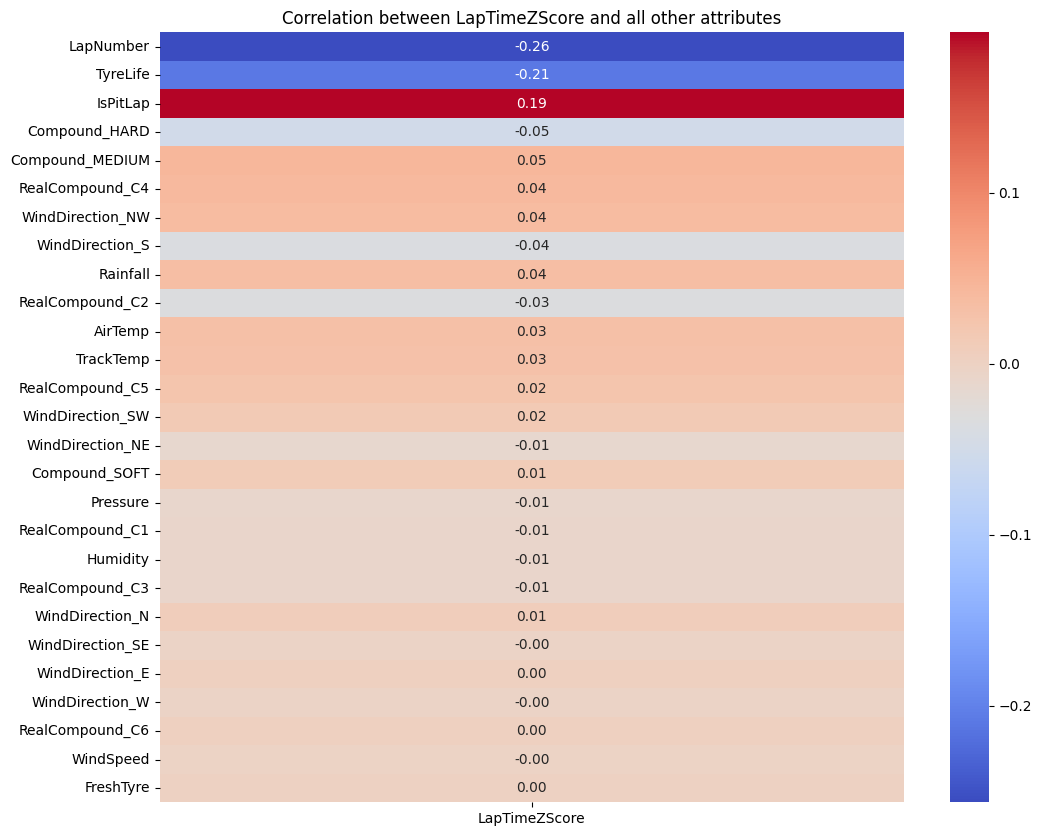

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(corrs), annot=True, fmt=".2f", cmap='coolwarm')

plt.title('Correlation between LapTimeZScore and all other attributes')
plt.show()